In [1]:
import pandas as pd
df = pd.read_csv('dataset.txt', sep='\t', header=None)
df.head()

,0
0,Well Prince so Genoa and Lucca are now just fa...
1,But I warn you if you don't tell me that this ...
2,It was in July 1805 and the speaker was the we...
3,With these words she greeted Prince Vasili Kur...
4,Anna Pavlovna had had a cough for some days


In [2]:
df = df.sample(frac=1).reset_index(drop=True)

In [3]:
df.head()

,0
0,George's Cross of the Fourth Class for courage...
1,The instant he had done this all Rostov's anim...
2,I beg your Majesty's pardon returned Balashev ...
3,He used to have a predilection for Bacchus
4,A rumble of Russian and French voices and laug...


In [4]:
df.shape

(33341, 1)

In [5]:
df = df.astype('string')

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [7]:
tokenizer = Tokenizer(oov_token="<OOV>")

In [8]:
tokenizer.fit_on_texts(df[0].astype(str))

In [9]:
len(tokenizer.word_index)

21912

In [10]:
input_sequences = []
for sentence in df[0]:
  tokenized_sentence = tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1,len(tokenized_sentence)):
    input_sequences.append(tokenized_sentence[:i+1])

In [11]:
len(input_sequences)

582849

In [12]:
max_len = max([len(x) for x in input_sequences])
max_len

307

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')

In [14]:
padded_input_sequences

array([[   0,    0,    0, ...,    0, 4145,  935],
       [   0,    0,    0, ..., 4145,  935,    5],
       [   0,    0,    0, ...,  935,    5,    2],
       ...,
       [   0,    0,    0, ..., 2554,    3,  668],
       [   0,    0,    0, ...,    3,  668,  811],
       [   0,    0,    0, ...,  668,  811, 1644]])

In [15]:
X = padded_input_sequences[:,:-1]

In [16]:
y = padded_input_sequences[:,-1]

In [17]:
X.shape

(582849, 306)

In [18]:
y.shape

(582849,)

In [19]:
# from tensorflow.keras.utils import to_categorical
# y = to_categorical(y,num_classes=21913)

In [20]:
y.shape

(582849,)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Dropout

In [22]:
model = Sequential()
model.add(Embedding(21913, 100, input_length=306))
model.add(LSTM(100))
model.add(Dropout(0.2))
model.add(Dense(21913, activation='softmax'))

In [23]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [25]:
history = model.fit(X,y,epochs=10,validation_split=0.2)

Epoch 1/10
14572/14572 [==============================] - 832s 57ms/step - loss: 6.2790 - accuracy: 0.1186 - val_loss: 5.8099 - val_accuracy: 0.1531
Epoch 2/10
14572/14572 [==============================] - 860s 59ms/step - loss: 5.5922 - accuracy: 0.1667 - val_loss: 5.5550 - val_accuracy: 0.1774
Epoch 3/10
14572/14572 [==============================] - 851s 58ms/step - loss: 5.3160 - accuracy: 0.1878 - val_loss: 5.4609 - val_accuracy: 0.1886
Epoch 4/10
14572/14572 [==============================] - 806s 55ms/step - loss: 5.1283 - accuracy: 0.2023 - val_loss: 5.4217 - val_accuracy: 0.1930
Epoch 5/10
14572/14572 [==============================] - 807s 55ms/step - loss: 4.9814 - accuracy: 0.2135 - val_loss: 5.4092 - val_accuracy: 0.1977
Epoch 6/10
14572/14572 [==============================] - 854s 59ms/step - loss: 4.8613 - accuracy: 0.2240 - val_loss: 5.4148 - val_accuracy: 0.1983
Epoch 7/10
14572/14572 [==============================] - 806s 55ms/step - loss: 4.7601 - accuracy: 0.2316

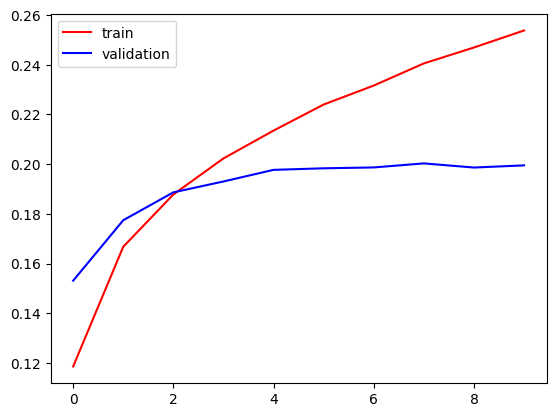

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

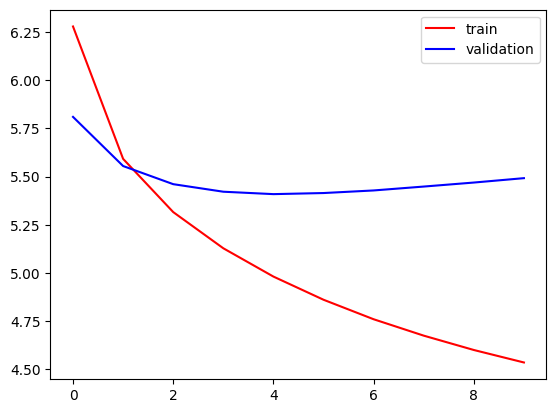

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [29]:
import numpy as np
import time
text = "I"

for i in range(10):
  # tokenize
  token_text = tokenizer.texts_to_sequences([text])[0]
  # padding
  padded_token_text = pad_sequences([token_text], maxlen=max_len-1, padding='pre')
  # predict
  pos = np.argmax(model.predict(padded_token_text))

  for word,index in tokenizer.word_index.items():
    if index == pos:
      text = text + " " + word
      print(text)
      time.sleep(2)

1/1 [==============================] - 0s 44ms/step
I am
1/1 [==============================] - 0s 43ms/step
I am confident
1/1 [==============================] - 0s 44ms/step
I am confident that
1/1 [==============================] - 0s 43ms/step
I am confident that we
1/1 [==============================] - 0s 44ms/step
I am confident that we can
1/1 [==============================] - 0s 48ms/step
I am confident that we can address
1/1 [==============================] - 0s 44ms/step
I am confident that we can address any
1/1 [==============================] - 0s 39ms/step
I am confident that we can address any challenges
1/1 [==============================] - 0s 39ms/step
I am confident that we can address any challenges that
1/1 [==============================] - 0s 42ms/step
I am confident that we can address any challenges that may


In [30]:
model.save("model.keras")

In [31]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)